# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [ ]:
import math
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [3]:
# YOUR CODE HERE

#loading the data 
df = pd.read_csv("https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/wine_quality_white/wine_quality_white.tsv.gz", sep='\t')
#picking out a sample of 10 random data
df.sample (n=10) 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
3788,6.6,0.270,0.52,8.1,0.044,53.0,202.0,0.99548,3.18,0.48,9.5,5
3041,6.2,0.330,0.41,16.8,0.037,58.0,173.0,0.99882,3.25,0.57,9.4,6
2721,8.2,0.370,0.64,13.9,0.043,22.0,171.0,0.99873,2.99,0.80,9.3,5
4653,6.3,0.360,0.28,2.5,0.035,18.0,73.0,0.98868,3.10,0.47,12.8,7
44,6.7,0.230,0.26,1.4,0.060,33.0,154.0,0.99340,3.24,0.56,9.5,6
48,7.0,0.310,0.26,7.4,0.069,28.0,160.0,0.99540,3.13,0.46,9.8,6
214,6.2,0.250,0.25,1.4,0.030,35.0,105.0,0.99120,3.30,0.44,11.1,7
1399,7.0,0.200,0.34,5.7,0.035,32.0,83.0,0.99280,3.19,0.46,11.5,6
800,7.8,0.270,0.58,11.2,0.036,44.0,161.0,0.99770,3.06,0.41,8.9,6
4792,4.7,0.785,0.00,3.4,0.036,23.0,134.0,0.98981,3.53,0.92,13.8,6


YOUR ANSWERS HERE

Here is the Wine Quality data set which has 4898 rows and 12 columns. The columns depict the different characteristics of the white wine sample. The target is the quality of the wine. 

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [ ]:
# YOUR CODE 
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='object')

YOUR ANSWERS HERE

Here we have the different characteristics of the wine.
1. Fixed acidity- the non-volatile acids in wine, which do not evaporate at normal temperatures; they are responsible for the crispness and structure of the wine
2. Volatile acidity- the oppositie of the fixed acidity which evaporates easily, they are composed of the acetic acid and ethyl acetate ; too much will be overpowering, pungent, and vinegar-y
3. Citric acid - natural organic acid, and is added to the wine to help with the acidity, freshness, and stability of the wine
4. Residual sugar - this is the leftover natural grape sugar (glucose and fructose) after the fermentation process; it determines how sweet the wine is; it separates a dry wine and a sweet wine 
5. Chlorides- the mineral salts from the geographic region due to soil, climate, and irrigation that contributes to the saltiness of the wine
6. Free sulfur dioxide - the active part of sulfur dioxide which protects the wine from spoiling and oxidation
7. Total sulfur dioxide - includes both the free and bound forms of sulfur dioxide; containes the free sulfur dioxide which is the active form; and bound sulfur dioxide which is attached to the sugars and aldehydes
8. Density- the specific gravity; calculated in mass per unit volume of wine at twenty degrees Celsius
9. pH - the measure of acidity of the wine; this impacts the taste, color, stability and quality of the wine; most wines are around pH 2.9 through 3.9
10. Sulphates- used as preservatives in the wine
11. Alcohol- the ethanol in the wine when yeast converts the sugars in the grape juice into alcohol and carbon dioxide; measured in ABV
12. Target - the wine quality scored by the raters

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

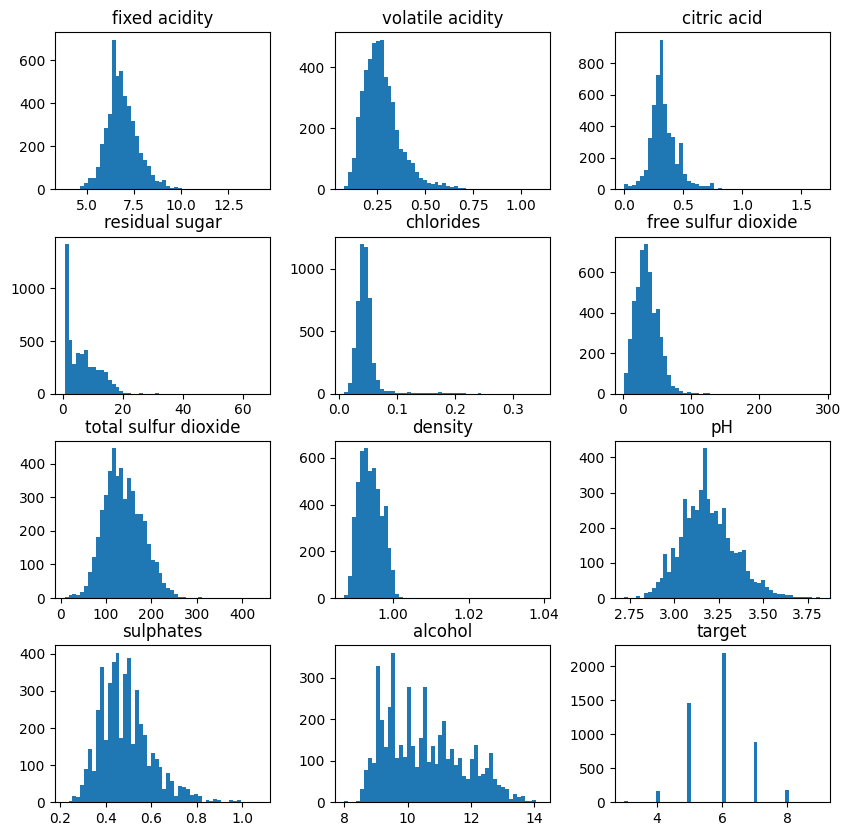

In [ ]:
# YOUR CODE HERE

# plotting the histogram with dimensions of my choice, no grids, and segments of 50 so it is easier to see 

df.hist (figsize= (10,10), grid = False, bins = 50)
plt.show()

YOUR ANSWERS HERE

1. Fixed acidity - approximately normal distribution; graph seems pretty uniformed and even
2. volatile acidity -  right skewed; there is a long tail off to the right signifying right skew
3. citric acid - right skewed ; shorter tail than volatile acidity but still more points to the right 
4. residual sugar -  right skewed; heavily more outliers off to the right
5. chlorides - right skewed; could see quite a few points laying in the 0.1-0.3 range
6. free sulfur dioxide -  right skewed; again mostly right skewed with couple outliers on the right
7. total sulfur dioxide - right skewed; mostly pretty even but more points to the right side
8. density - approximately normal distribution ; pretty even distribution 
9. pH - approximately normal distribution; a bell shaped curve
10. sulphates - right skewed; trailing tail on the right determinng the right skew
11. alcohol - right skewed; points are trailing off to the right here
12. target  - discrete; normal ; sort of bell curve is pictured here

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

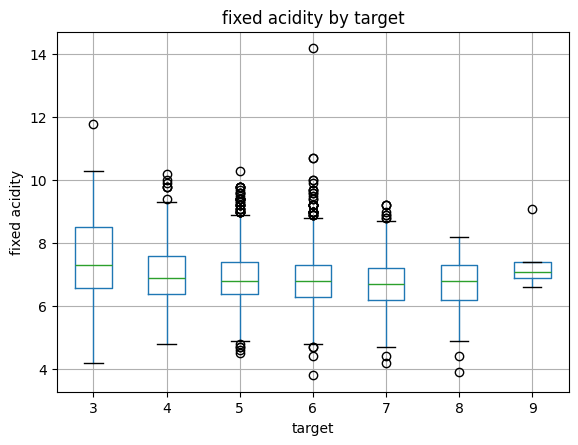

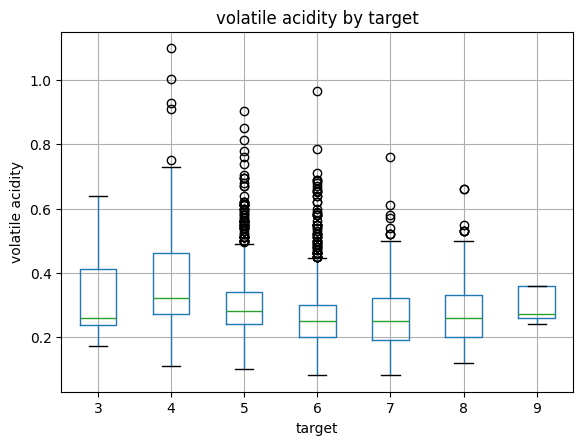

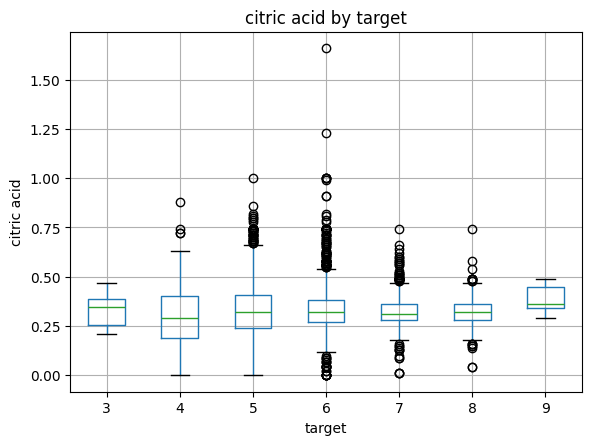

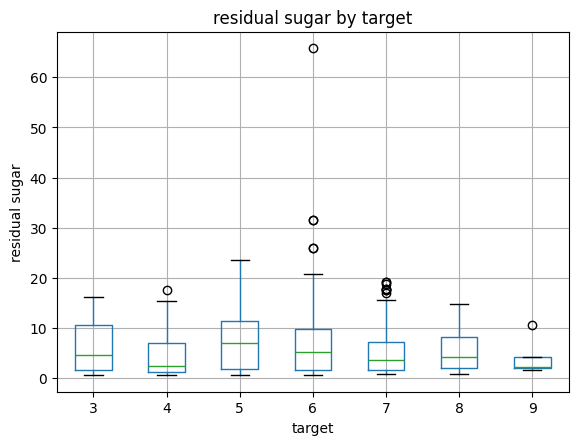

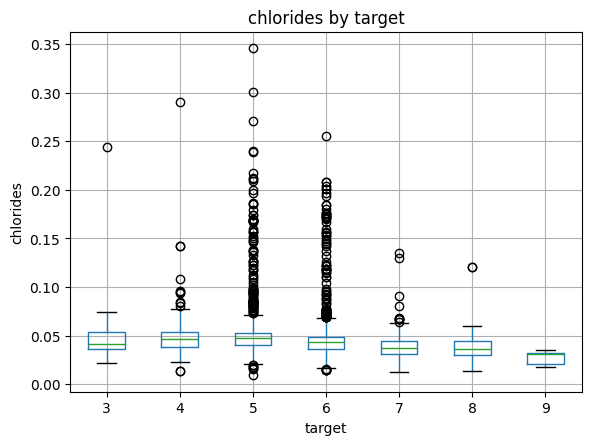

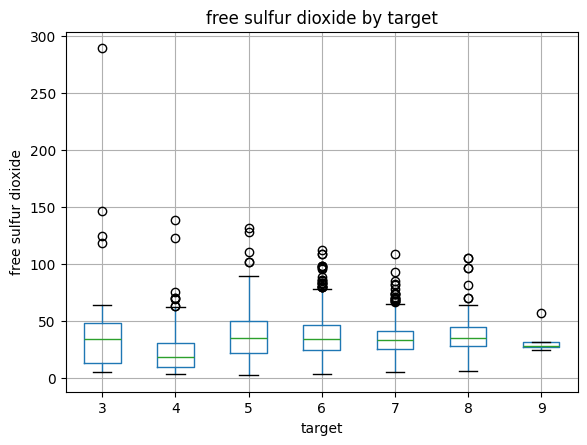

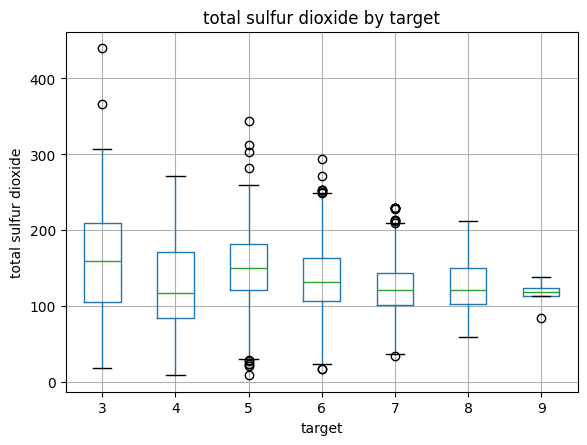

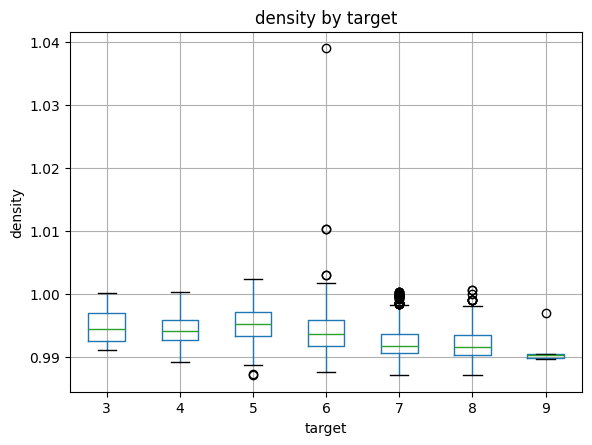

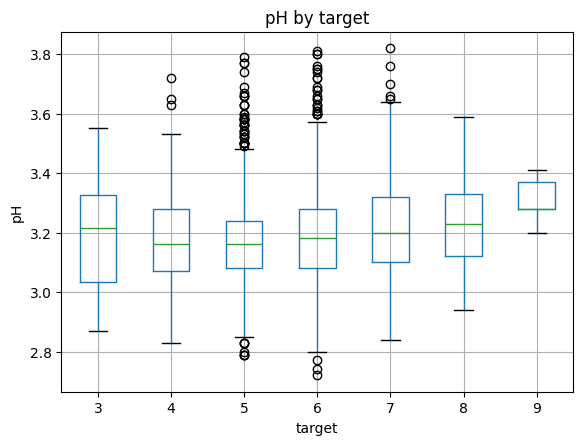

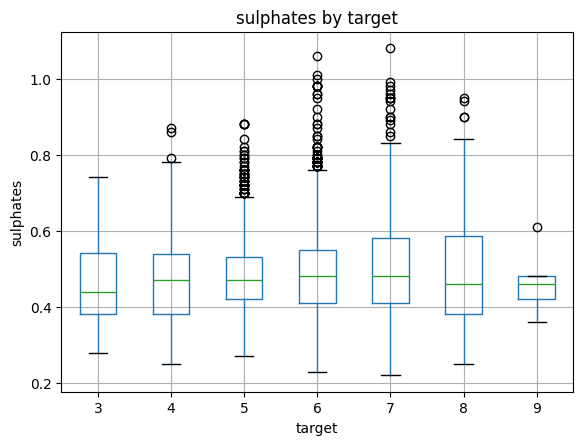

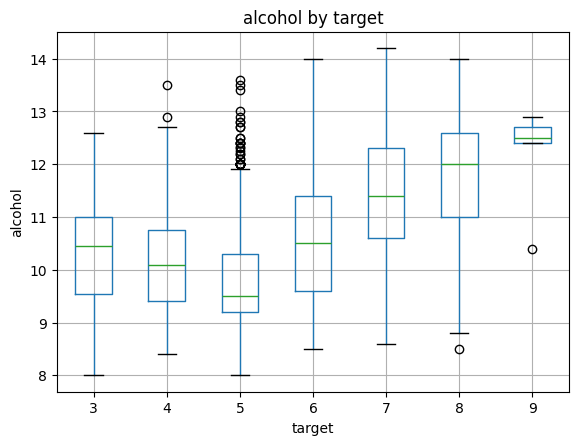

In [5]:
# YOUR CODE HERE

# picking out all the columns except the target one
columns = df.columns.drop ("target")

# making the boxplot for each input column against target
for col in columns:
    df.boxplot (column = col, by = 'target')
    plt.suptitle ("")
    plt.title(f"{col} by target")
    plt.ylabel (col)

YOUR ANSWERS HERE
Independence or not independence (dependence)

1. fixed acidity- Independent; most of the values remained the same across the target quality
2. volatile acidity - Independent; like fixed acidity no trend related to the target quality
3. citric acid - Independent; relatively the same across the trend
4. residual sugar - independent ; no clear trend across the target quality
5. chlorides - dependent; there is a gradual downward trend as the target increases; the chlorides decreaseas quality of wine increase
6. free sulfur dioxide- independent; no clear trend depicted
7. total sulfur dioxide - independent; the median stays the same across the target quality
8. density - dependent; another downward trend as the target increases
9. pH - dependent; slight upward trend as the target increases 
10. sulphates- independent; relatively the same median across the target quality
11. alcohol - dependent; strong upward trend as alcohol content increases, target also increases

** my indicator for independence and dependence
independence = if the median of the boxplot stayed relatively the same throughout the whole plot with no trend of upward or downwards, I classified as independence; the input does not affect the target
dependence = if the median of the boxplot had some sort of trend going pointing more positive or negative as the quality increases, I classified as dependence; the input affects the target

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

Mean Squared Error: 0.5631540629886564


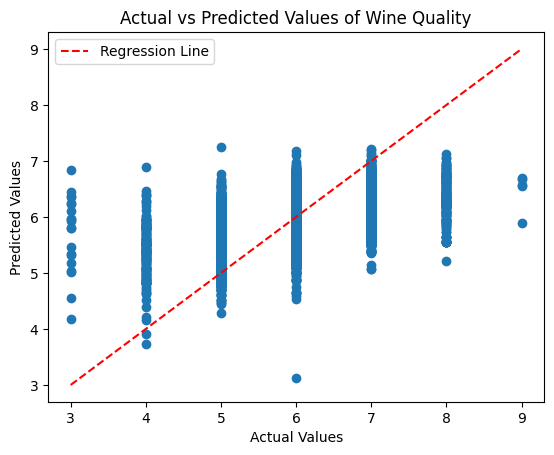

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#setting the variables for x and y
x = df.drop(columns = ["target"])
y = df["target"]
model = LinearRegression()
model.fit (x,y)

#doing the mean squared error and equation
y_pred = model.predict(x)
mse = np.mean((y - y_pred)** 2)
print ("Mean Squared Error:" , mse)

#plotting the graph of actual and predicted
plt.scatter(y, y_pred)
plt.xlabel ("Actual Values")
plt.ylabel ("Predicted Values")
plt.title("Actual vs Predicted Values of Wine Quality")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label = "Regression Line")
plt.legend()
plt.show()

YOUR ANSWERS HERE

The mean squared error of the average squared diffence between the predicted and actual wine quality was 0.563. A lower MSE means a better fit of the model to the data. We can see in the graph there is a positive linear trend close to the actual values. 

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [7]:
# YOUR CODE HERE

columns = df.columns.drop("target")

#creating the dictionary for when it will be looped
results = {}

for col in columns:
    x= df[[col]]
    y= df["target"]
    model = sklearn.linear_model.LinearRegression() # making the model
    model.fit(x, y)
    y_pred = model.predict(x)
    mse = np.mean((y - y_pred) ** 2) # calculating the MSE 
    results[col] = mse

# printing all the MSE results from each column 
    print(f"{col:20} MSE = {mse:.4f}")





fixed acidity        MSE = 0.7741
volatile acidity     MSE = 0.7545
citric acid          MSE = 0.7841
residual sugar       MSE = 0.7767
chlorides            MSE = 0.7496
free sulfur dioxide  MSE = 0.7841
total sulfur dioxide MSE = 0.7603
density              MSE = 0.7102
pH                   MSE = 0.7764
sulphates            MSE = 0.7819
alcohol              MSE = 0.6354


YOUR ANSWERS HERE

Alcohol had the lowest MSE value of 0.6354. This means that it is the strongest predictor of wine quality. Problem 5 used all the input features which resulted in a lower MSE of 0.563. This means that all the features combined are better predictors than just one feature of the data set, even though alcohol has the strongest of them all. 

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

Threshold: 10.400000


Text(0, 0.5, 'Count')

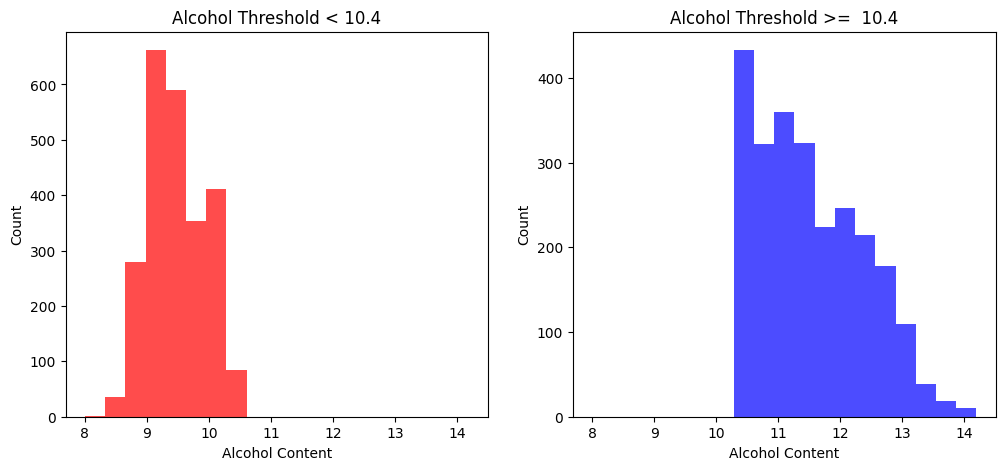

In [ ]:
# YOUR CODE HERE

#picking the threshold for my columns
t= df ['alcohol'].median()
print (f"Threshold: {t:3f}")

#splitting using threshold
below_half = df['alcohol'] < t
top_half = df['alcohol'] >= t

# have them side by side
plt.figure(figsize= (12,5))

# Have the same bins for both 
bins = np.linspace(df['alcohol'].min(), df['alcohol'].max(), 20)

# Suplot #1 for the below threshold
plt.subplot(1,2,1)
plt.hist(below_data["alcohol"], bins = bins, color ='red', alpha = 0.7)
plt.title ("Alcohol Threshold < 10.4")
plt.xlabel ("Alcohol Content")
plt.ylabel ("Count")

#Subplot #2 for the above threshold
plt.subplot(1,2,2)
plt.hist(top_data ["alcohol"], bins = bins, color ='blue', alpha = 0.7)
plt.title ("Alcohol Threshold >=  10.4")
plt.xlabel ("Alcohol Content")
plt.ylabel ("Count")


YOUR ANSWERS HERE

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

In [ ]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

YOUR ANSWER HERE